# CGAN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Usando {DEVICE}.')

Usando mps.


## Datos de entrenamiento

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),  # [0, 1]
    transforms.Normalize((0.5,), (0.5,))  # normalización a [-1, 1].
])

dataset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True, num_workers=2)

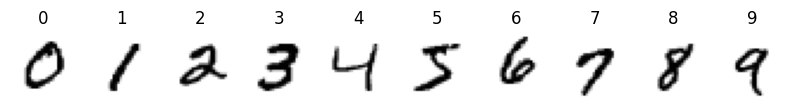

In [ ]:
# Ejemplo:
fig, axes = plt.subplots(1, 10, figsize=(10, 1.2))
for cond in range(10):
    idx = (dataset.targets == cond).nonzero()[0].item()
    x, cond_true = dataset[idx]
    img = x.permute(1, 2, 0) * 0.5 + 0.5  # desnormalización a [0, 1].
    axes[cond].imshow(img, cmap='gray_r')
    axes[cond].set_title(cond_true)
    axes[cond].axis('off')
plt.show()

## Redes neuronales

In [4]:
class Generator(nn.Module):

    def __init__(self, data_dim, n_classes, cond_embed_dim, latent_dim):
        super().__init__()
        self.cond_embed = nn.Embedding(n_classes, cond_embed_dim)
        self.net = nn.Sequential(
            nn.Linear(latent_dim + cond_embed_dim, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512), nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024), nn.BatchNorm1d(1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, data_dim), nn.Tanh()
        )
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0.0, 0.02)
            nn.init.zeros_(m.bias)

    def forward(self, z, cond):
        cond = self.cond_embed(cond)
        input = torch.cat([z, cond], dim=1)
        return self.net(input)


class Discriminator(nn.Module):

    def __init__(self, data_dim, n_classes, cond_embed_dim):
        super().__init__()
        self.cond_embed = nn.Embedding(n_classes, cond_embed_dim)
        self.net = nn.Sequential(
            nn.Linear(data_dim + cond_embed_dim, 1024), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(1024, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256, 1)
        )
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0.0, 0.02)
            nn.init.zeros_(m.bias)

    def forward(self, x, cond):
        cond = self.cond_embed(cond)
        input = torch.cat([x.flatten(1), cond], dim=1)
        return self.net(input)


## Entrenamiento

In [5]:
def train(generator, discriminator, latent_dim, epochs=50, label_smoothing=0.9, g_steps=2):

    generator.to(DEVICE).train()
    discriminator.to(DEVICE).train()

    # Optimizadores:
    generator_optimizer = optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

    criterion = nn.BCEWithLogitsLoss()
    losses = {'generator': [], 'discriminator': []}

    try:
        for epoch in tqdm(range(epochs)):
            for x_true, cond_true in dataloader:
                batch_size = len(x_true)
                ones = torch.ones(batch_size, 1, device=DEVICE)
                zeros = torch.zeros(batch_size, 1, device=DEVICE)

                # Datos de entrenamiento:
                # - True:
                cond_true = cond_true.to(DEVICE)
                x_true = x_true.to(DEVICE)
                # - Fake:
                z = torch.randn(batch_size, latent_dim, device=DEVICE)
                x_fake = generator(z, cond_true)

                # Entrenamiento discriminador:
                # - Loss:
                loss_d_real = criterion(discriminator(x_true, cond_true), ones * label_smoothing)
                loss_d_fake = criterion(discriminator(x_fake.detach(), cond_true), zeros)
                loss_discriminator = 1/2 * (loss_d_real + loss_d_fake)
                # - Step:
                discriminator_optimizer.zero_grad()
                loss_discriminator.backward()
                discriminator_optimizer.step()

                # Entrenamiento generador:
                for _ in range(g_steps):
                    z = torch.randn(batch_size, latent_dim, device=DEVICE)
                    x_fake = generator(z, cond_true)
                    loss_generator = criterion(discriminator(x_fake, cond_true), ones)
                    generator_optimizer.zero_grad()
                    loss_generator.backward()
                    generator_optimizer.step()

                # Log:
                losses['generator'].append(loss_generator.item())
                losses['discriminator'].append(loss_discriminator.item())

    except KeyboardInterrupt:
        print('Entrenamiento interrumpido.')

    # Gráfico de entrenamiento:
    plt.plot(losses['generator'], label='Generador', alpha=0.7)
    plt.plot(losses['discriminator'], label='Discriminador', alpha=0.7)
    plt.xlabel('Step');
    plt.ylabel('Loss');
    plt.legend();
    plt.grid(alpha=0.3)
    plt.show()


  0%|          | 0/50 [00:00<?, ?it/s]

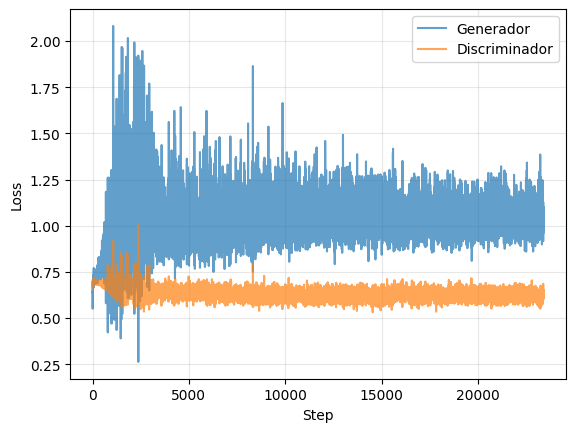

In [6]:
data_dim = dataset[0][0].numel()
n_classes = len(dataset.classes)
cond_embed_dim = 16
latent_dim = 64

generator = Generator(data_dim, n_classes, cond_embed_dim, latent_dim)
discriminator = Discriminator(data_dim, n_classes, cond_embed_dim)

train(generator, discriminator, latent_dim)

## Generación

In [7]:
@torch.no_grad()
def generate_samples(cond, n_samples):
    generator.eval()
    z = torch.randn(n_samples, latent_dim, device=DEVICE)
    cond = torch.full((n_samples,), cond, dtype=torch.long, device=DEVICE)
    samples = generator(z, cond)
    return samples.cpu()

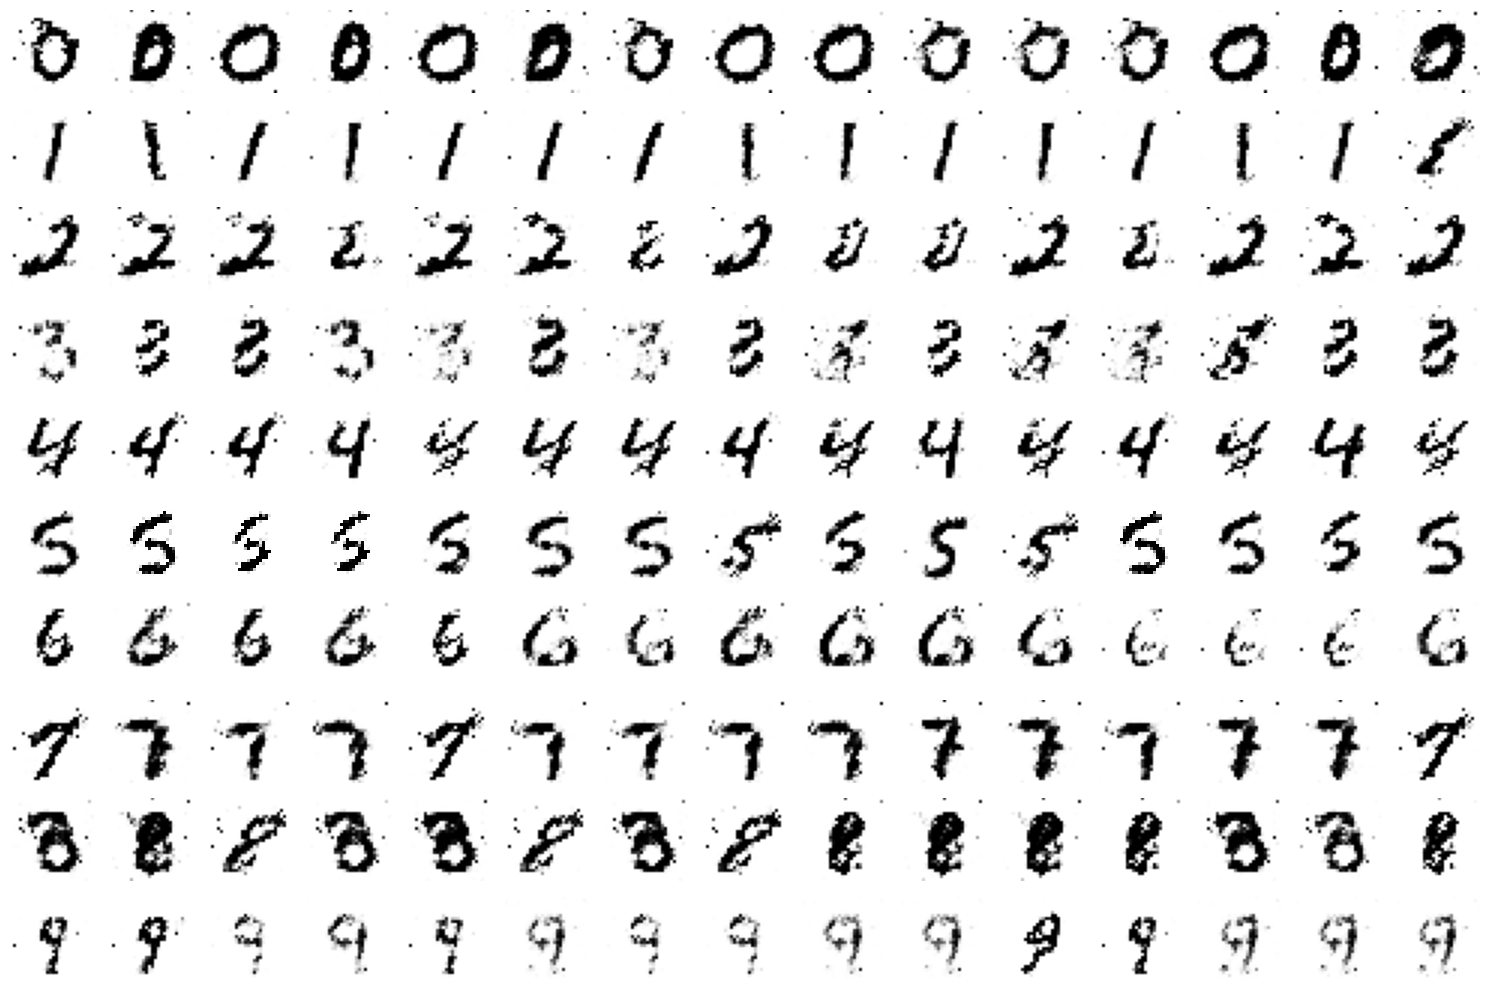

In [8]:
n_samples = 15

fig, axes = plt.subplots(n_classes, n_samples, figsize=(n_samples, n_classes))
for cond in range(n_classes):
    samples = generate_samples(cond=cond, n_samples=n_samples)
    samples = (samples * 0.5 + 0.5).clamp(0, 1).view(len(samples), 28, 28)
    for j in range(n_samples):
        axes[cond, j].imshow(samples[j], cmap='gray_r')
        axes[cond, j].axis('off')
    axes[cond, 0].set_ylabel(str(cond), fontsize=10)
plt.tight_layout()
plt.show()